# Cost–Time Model Accuracy

Model vs. measurement on TPC-H SF100 (19 queries × 3 systems × 15 runs, Grid'5000).

The CSVs in `data/` were exported from the measured runs with `cofi/accuracy.py`

The file `pipeline/` holds the CoFi-FaaS query pipelines (`q*.yml.j2`) and their TPC-H parameters (`parms-tpch-100.json`).

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cofi import style

%matplotlib inline

style.apply()
FONT_SIZE = style.FONT_SIZE
DATA, FIG = "data", "figures"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.width", 160)
qnum = lambda q: int("".join(c for c in q if c.isdigit()) or 0)

SYS   = ["base", "s3", "nfs"]
LABEL = {"base": "CoFi-FaaS", "s3": "CoFi-FaaS S3", "nfs": "CoFi-FaaS FS"}
COLOR = {"base": "#2a78d6", "s3": "#eb6834", "nfs": "#1baf7a"}
RUNS = {c: pd.read_csv(f"{DATA}/runs-{c}.csv") for c in ("v5", "paper")}

BF = pd.read_csv(f"{DATA}/bf-v5.csv")
KAPPA = json.load(open(f"{DATA}/kappa-v5.json"))
RUNS["v5"].head()

,query,system,run,metric,meas,model,err_%,abs_err_%
0,q2,s3,1,T,4.612088,4.360789,-5.448712,5.448712
1,q2,s3,1,C,0.001197,0.001546,29.172122,29.172122
2,q2,base,1,T,7.611147,7.019194,-7.777452,7.777452
3,q2,base,1,C,0.004427,0.004780,7.979212,7.979212
4,q2,s3,1,decision,1.000000,1.000000,0.000000,0.000000


## MAPE


In [2]:
def per_query(df):
    acc = df[df.metric.isin(["T", "C"])]
    return acc.groupby(["query", "system", "metric"]).agg(meas=("meas", "median"), model=("model", "median"), err=("err_%", "median"), mape=("abs_err_%", "mean")).reset_index()

PQ = {c: per_query(df) for c, df in RUNS.items()}
tab = {}
for c, pq in PQ.items():
    s = pq.pivot_table(index="system", columns="metric", values="mape", aggfunc="mean").reindex(SYS)
    s.loc["all"] = pq.groupby("metric")["mape"].mean()
    tab[c] = s[["T", "C"]]

tab = pd.concat(tab, axis=1).round(1)
tab.index = [LABEL.get(i, "All systems") for i in tab.index]
tab

v5       paper      
metric           T     C     T     C
CoFi-FaaS     18.0  12.5  54.5  26.3
CoFi-FaaS S3  16.5  13.4  51.6  35.7
CoFi-FaaS FS  18.5  20.4  69.5  59.8
All systems   17.7  15.4  58.5  40.6

## Absolute error per query (left) and average per system (right), v5

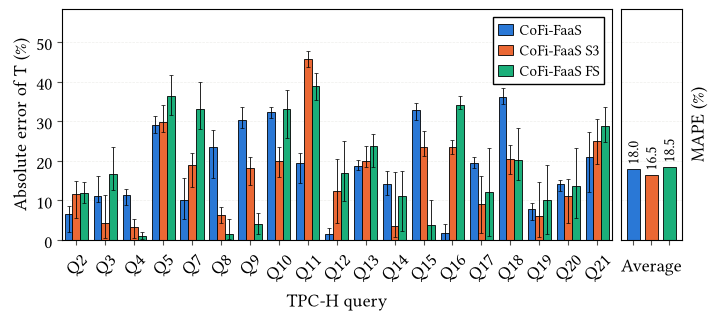

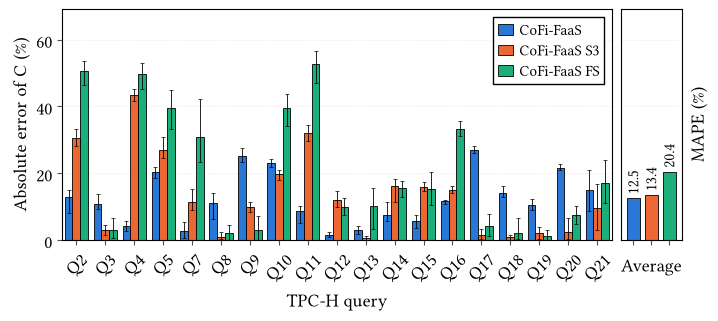

In [3]:
runs = RUNS["v5"]
ABS = runs[runs.metric.isin(["T", "C"])].groupby(["query", "system", "metric"])["abs_err_%"].agg(mean="mean", lo="min", hi="max")
QUERIES = sorted(runs["query"].unique(), key=qnum)


def plot_abs_err(M, ylabel, figsize=(8, 3), ytop=None, name=None):
    d = ABS.xs(M, level="metric")
    bw = 0.8 / len(SYS)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True, gridspec_kw={"width_ratios": [0.9, 0.1], "wspace": 0.03})
    for k, s in enumerate(SYS):
        qs = [q for q in QUERIES if (q, s) in d.index]
        xs = np.array([QUERIES.index(q) for q in qs]) + (k - (len(SYS) - 1) / 2) * bw
        v = d.loc[[(q, s) for q in qs]]
        ax.bar(xs, v["mean"], bw, color=COLOR[s], edgecolor="black", linewidth=0.6, label=LABEL[s],
               yerr=[v["mean"] - v["lo"], v["hi"] - v["mean"]],
               error_kw={"elinewidth": 0.6, "capsize": 1.5, "capthick": 0.5, "ecolor": "black"}, zorder=2)

    ax.set_xticks(range(len(QUERIES)), [q.upper() for q in QUERIES], rotation=45)
    ax.set_xlim(-0.5, len(QUERIES) - 0.5)
    ax.set_ylim(0, ytop or d["hi"].max() * 1.22)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("TPC-H query")

    ax.legend(loc="upper right", frameon=True, edgecolor="black", fancybox=False, framealpha=1, fontsize=FONT_SIZE - 2,
              borderpad=0.3, labelspacing=0.2, handlelength=1.0, handletextpad=0.4)
    avg = [d.xs(s, level="system")["mean"].mean() for s in SYS]
    bars = ax2.bar(range(len(SYS)), avg, 0.7, color=[COLOR[s] for s in SYS], edgecolor="black", linewidth=0.6, zorder=2)

    for b, v in zip(bars, avg):
        ax2.annotate(f"{v:.1f}", (b.get_x() + b.get_width() / 2, v), xytext=(0, 3), textcoords="offset points",
                     ha="center", va="bottom", rotation=90, fontsize=FONT_SIZE - 2)

    ax2.set_xticks(range(len(SYS)), [])
    ax2.set_xlim(-0.7, len(SYS) - 0.3)
    ax2.set_xlabel("Average")
    ax2.tick_params(axis="y", left=False)
    ax2.set_ylabel("MAPE (%)")
    ax2.yaxis.set_label_position("right")
    for a in (ax, ax2):
        a.grid(axis="x", visible=False)
        a.grid(axis="y", alpha=0.6, linestyle="--")
        a.set_axisbelow(True)
        for sp in a.spines.values():
            sp.set_color("black"); sp.set_linewidth(0.8)
    if name:
        style.save(fig, FIG, name)
    plt.show()

# Save the chart
plot_abs_err("T", "Absolute error of T (%)", name="cost-accuracy-err-T")
plot_abs_err("C", "Absolute error of C (%)", name="cost-accuracy-err-C")

## Per-query values (median over runs)

In [4]:
t = PQ["v5"].pivot_table(index="query", columns=["metric", "system"], values="err").reindex(QUERIES).round(1)
t.index = [q.upper() for q in t.index]
t

metric     C                 T            
system  base   nfs    s3  base   nfs    s3
Q2      13.7  51.1  30.5   6.7  12.5  11.9
Q3     -10.6  -3.0  -2.6 -10.7 -15.8  -4.1
Q4       4.3  50.3  43.4 -11.7  -0.3   3.7
Q5     -20.1 -39.1 -26.4 -28.7 -35.7 -29.2
Q7       2.4 -28.7 -10.8 -10.8 -33.2 -19.0
Q8     -11.4  -2.3  -0.8 -24.5  -1.2   6.3
Q9     -24.9   2.3  10.0 -29.8  -3.9  17.9
Q10    -23.0 -40.2 -19.9 -32.6 -34.0 -21.0
Q11      8.7  53.2  32.2  20.0  39.1  46.2
Q12     -1.7 -10.1 -11.9  -1.5 -17.2 -11.5
Q13      2.7 -10.7   0.2 -18.4 -24.4 -19.8
Q14     -7.5 -15.4 -16.1  14.4 -13.7  -2.0
Q15     -5.8 -15.0 -15.8  33.0   2.1  22.9
Q16     11.7  33.1  15.0  -1.3 -33.8 -23.6
Q17    -27.2   4.1   1.7 -19.6   8.9   8.0
Q18    -14.0   0.3   0.6 -35.9 -20.8 -20.5
Q19    -10.5   0.4  -2.3   8.0   6.1   2.5
Q20    -21.6   7.2   1.8 -14.0  14.1  11.3
Q21    -15.1 -16.8 -10.4 -20.9 -29.0 -26.4

## Bloom-filter decision and demand

* **Decision**: for every BF run paired with a no-BF run, does the model agree with the measurement on whether BF
  pushdown is both faster and cheaper?
* **Extra requests** R_j = 2 p^b_j + 1 + p^p_j vs. the counted BF reads / writes.
* **Pass rate** φ_j = σ_j + (1 − σ_j) f_j vs. the measured rows kept by the BF. σ_j is measured on the no-BF run
  at the first join whose inputs contain the BF builder and the filtered scan; in multi-join queries this is not
  always the join the filter targets (e.g. Q9, Q21), which shows up as large φ errors below.

In [5]:
d = RUNS["v5"]
dec = d[d.metric == "decision"].groupby("system")["err_%"].agg(match=lambda s: int((s == 0).sum()), runs="count")
print(dec.rename(index=LABEL))
print(f"\nextra BF requests R_j: model == measured for {int((BF.R_model == BF.R_meas).sum())}/{len(BF)}")
g = BF.groupby(["query", "bf", "applier"]).agg(sigma=("sigma_semi", "median"), phi_meas=("phi_meas", "median"),
                                              phi_model=("phi_model", "median"), err_phi=("err_phi_%", "median")).reset_index()
ok = g.err_phi.abs() <= 5
print(f"pass rate phi_j within 5%: {int(ok.sum())}/{g.err_phi.notna().sum()} (BF, applier)")
g.sort_values("query", key=lambda s: s.map(qnum)).round(3)

              match  runs
system                   
CoFi-FaaS FS    234   285
CoFi-FaaS S3    241   285

extra BF requests R_j: model == measured for 510/510
pass rate phi_j within 5%: 22/31 (BF, applier)


,query,bf,applier,sigma,phi_meas,phi_model,err_phi
12,q2,step1-region--mergebf,step2-nation,0.200,0.400,0.200,-50.000
13,q2,step3-join-region-nation--mergebf,step4-supplier,0.200,0.200,0.200,-0.122
14,q2,step5-part--mergebf,step6-partsupp,0.004,0.004,0.004,-0.101
22,q3,Step3-join-customer-orders--mergebf,Step4-lineitem,0.009,0.158,0.158,-0.009
21,q3,Step1-customer--mergebf,Step2-orders,0.200,0.200,0.200,-0.003
23,q4,step1-orders--mergebf,step2-lineitem,0.038,0.038,0.038,-0.005
26,q5,step3-join-region-nation--mergebf,step5-customer,0.200,0.200,0.200,-0.055
25,q5,step3-join-region-nation--mergebf,step4-supplier,0.200,0.200,0.200,-0.026
24,q5,step1-region--mergebf,step2-nation,0.200,0.200,0.200,0.000
28,q7,step1-nation--mergebf,step3-customer,0.080,0.080,0.080,0.186


## Calibrated platform parameters κ


In [6]:
K = KAPPA
rows = {"κ^bw S3 (MB/s)": [k["bw"]["s3"] / 1e6 for k in K.values()],
        "κ^lat S3 (ms)": [k["lat"]["s3"] * 1e3 for k in K.values()],
        "κ^bw NFS (MB/s)": [k["bw"]["nfs"] / 1e6 for k in K.values()],
        "κ^lat NFS (ms)": [k["lat"]["nfs"] * 1e3 for k in K.values()],
        "κ^disp (ms)": [k["disp"] * 1e3 for k in K.values()],
        "β S3 (ms per MB per concurrent function)": [k["beta"].get("s3", 0) * 2**20 * 1e3 for k in K.values()]}
for e in sorted({e for k in K.values() for e in k["rate"]}):
    rows[f"κ^cpu {e} (MB/s per vCPU)"] = [k["rate"][e] / 1e6 if k["rate"][e] < 1e14 else np.inf for k in K.values() if e in k["rate"]]

pd.DataFrame({n: {"median": np.median(v), "min": np.min(v), "max": np.max(v)} for n, v in rows.items()}).T.style.format("{:.2f}")

,median,min,max
κ^bw S3 (MB/s),230.72,200.24,252.78
κ^lat S3 (ms),0.00,0.00,0.00
κ^bw NFS (MB/s),843.76,843.61,919.66
κ^lat NFS (ms),0.95,0.92,1.28
κ^disp (ms),52.29,43.51,54.46
β S3 (ms per MB per concurrent function),0.33,0.31,0.34
κ^cpu /aggregate@nfs (MB/s per vCPU),38.22,32.46,62.13
κ^cpu /aggregate@s3 (MB/s per vCPU),34.58,32.28,41.07
κ^cpu /join@nfs (MB/s per vCPU),inf,431.15,inf
κ^cpu /join@s3 (MB/s per vCPU),55.75,42.46,72.32


## Accuracy per component: function, stage, query

The query time is built in three steps, each compared with the measurement (`data/components-v5.csv`,
`python -m cofi.components`, v5 model, κ calibrated leave-one-query-out):
* **Function** — time of one function (execution + dispatch) vs. the measured mean over the stage's functions;
* **Stage** — the functions composed into waves of `max_parallel` vs. the measured stage wall time;
* **Query** — the stages one after another vs. the measured query time.

Two data sets: **accuracy** = the runs of this section (default partition size), **sweep** = BLOOM-FaaS S3 at other
partition sizes (10–200 MB, Q3 / Q9 / Q18), never used for calibration. Errors are time-weighted
(Σ|model − meas| / Σ meas), so the many sub-second stages do not dominate; bias = Σ(model − meas) / Σ meas.

In [7]:
CP = pd.read_csv(f"{DATA}/components-v5.csv")
LEVELS = [("Function", "task_model", "task_meas_mean"), ("Stage", "stage_model", "stage_meas"), ("Query", "T_model", "T_meas")]


def level_err(df, model, meas):
    if model == "T_model":                                  # one row per run for the query level
        df = df.drop_duplicates(["dataset", "query", "system", "size_mb", "run"])
    e = df[model] - df[meas]
    return pd.Series({"error (%)": 100 * e.abs().sum() / df[meas].sum(), "bias (%)": 100 * e.sum() / df[meas].sum(),
                      "n": len(df)})


rows = []
for ds, g in CP.groupby("dataset"):
    for lab, mo, me in LEVELS:
        rows.append({"data set": ds, "level": lab, **level_err(g, mo, me)})
COMP = pd.DataFrame(rows).set_index(["data set", "level"])
COMP["n"] = COMP["n"].astype(int)
display(COMP.round(1))

# function and stage level by stage size (functions per stage), BLOOM-FaaS S3 runs of both data sets
CP["size"] = pd.cut(CP["p"], [0, 1, 70, 210, 10**6], labels=["1", "2–70 (1 wave)", "71–210 (2–3 waves)", ">210"])
by = []
for (ds, sz), g in CP[CP.system == "s3"].groupby(["dataset", "size"], observed=True):
    f, s = level_err(g, "task_model", "task_meas_mean"), level_err(g, "stage_model", "stage_meas")
    by.append({"data set": ds, "functions per stage": sz, "stages": len(g),
               "function error (%)": f["error (%)"], "function bias (%)": f["bias (%)"],
               "stage error (%)": s["error (%)"], "stage bias (%)": s["bias (%)"]})
display(pd.DataFrame(by).set_index(["data set", "functions per stage"]).round(1))

error (%)  bias (%)      n
data set level                               
accuracy Function       35.0      -4.9  14070
         Stage          30.0     -15.8  14070
         Query          21.3     -17.1    855
sweep    Function       39.3      15.2   3352
         Stage          33.6       2.0   3352
         Query          12.8      -0.0    187

stages  function error (%)  function bias (%)  stage error (%)  stage bias (%)
data set functions per stage                                                                                
accuracy 1                      2880                34.9               11.2             34.8            11.1
         2–70 (1 wave)          1665                36.0                9.3             33.6           -10.7
         71–210 (2–3 waves)      249                26.4              -25.9             22.9           -17.4
         >210                     66                25.8              -10.1             16.6            -4.8
sweep    1                      1153                35.5               -6.1             35.3            -6.3
         2–70 (1 wave)          1803                43.4               26.9             39.0            -0.9
         71–210 (2–3 waves)      276                26.8              -18.4             24.8            -7.2
         >210                    120                24.7                7.2             26.0            20.1

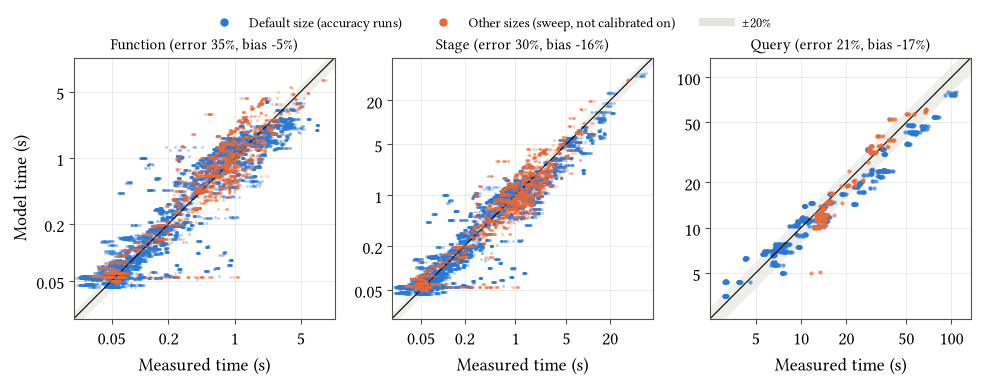

In [8]:
from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter
NICE = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
DS_STYLE = {"accuracy": ("#2a78d6", "Default size (accuracy runs)"), "sweep": ("#eb6834", "Other sizes (sweep, not calibrated on)")}
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, (lab, mo, me) in zip(axs, LEVELS):
    d = CP if mo != "T_model" else CP.drop_duplicates(["dataset", "query", "system", "size_mb", "run"])
    d = d[(d[me] > 0) & (d[mo] > 0)]
    for ds, (col, _) in DS_STYLE.items():
        g = d[d.dataset == ds]
        ax.scatter(g[me], g[mo], s=4 if mo != "T_model" else 9, color=col, alpha=0.35 if mo != "T_model" else 0.7, lw=0,
                   zorder=2 if ds == "accuracy" else 3, rasterized=True)
    lo, hi = min(d[me].quantile(0.005), d[mo].quantile(0.005)) * 0.8, max(d[me].max(), d[mo].max()) * 1.25
    xs = np.geomspace(lo, hi, 50)
    ax.plot(xs, xs, color="black", lw=0.8); ax.fill_between(xs, xs * 0.8, xs * 1.2, color=style.GRID, alpha=0.6, lw=0, zorder=0)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ticks = [t for t in NICE if lo <= t <= hi]
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(FixedLocator(ticks[::2] if len(ticks) > 6 else ticks)); axis.set_minor_locator(NullLocator())
        axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    e = COMP.loc[("accuracy", lab)]
    ax.set_title(f"{lab} (error {e['error (%)']:.0f}%, bias {e['bias (%)']:+.0f}%)", fontsize=FONT_SIZE - 2)
    ax.set_xlabel("Measured time (s)")
    ax.grid(True, color=style.GRID); ax.set_axisbelow(True)
axs[0].set_ylabel("Model time (s)")
h = [plt.Line2D([], [], ls="", marker="o", ms=5, color=c) for c, _ in DS_STYLE.values()] + [plt.Line2D([], [], color=style.GRID, lw=6)]
fig.legend(h, [l for _, l in DS_STYLE.values()] + ["±20%"], loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.08), fontsize=FONT_SIZE - 3)
fig.tight_layout()
style.save(fig, FIG, "accuracy-components")
plt.show()